# Pseudospectral Methods, Part XV: Hierarchical Search — Partitioning Large Areas

The Dubins-search machinery from Parts X–XIII handles areas that fit comfortably in a single
tour. Reality is harder: the search area is often **much larger** than what one drone can
cover in the available time. A maritime SAR mission might assign a $\sim 50\,\mathrm{km} \times 50\,\mathrm{km}$
search box to one drone with a 4-hour battery — but the actual ocean region of interest is
$300 \times 300$ km. Wildlife surveys, mine detection, atmospheric sampling — same story. The
**low-level Dubins-search NLP we already have** is one tool; the **outer partitioning problem**
is something different.

This notebook builds the second piece. Given a per-cell search optimizer (Parts X-XIII), we ask:

> **How do we slice a large search area into cells, and which cells deserve our limited time?**

There are two cleanly-different framings:

**Framing A (orienteering / selective TSP).** Cells are *fixed* (a uniform grid, predetermined
strips, etc.); the question is which subset to visit, in what order, with what time allocation.
Mathematically: orienteering problem — pick a subset of nodes in a graph maximizing total
"profit" subject to a tour-length budget. NP-hard in general, but heuristically tractable.

**Framing B (centroidal Voronoi tessellation, CVT).** Cells are *variable*; we get to choose
their shapes. The optimal partitioning (under appropriate metrics) places more cells where the
prior is dense, fewer where it's sparse — exactly what k-means / Lloyd's algorithm computes
for density-weighted vector quantization. Each cell ends up with comparable prior mass; cell
*size* adapts to local density.

Both framings can be used together. We'll cover B first (it's the more elegant math) and then
return to A when the budget is genuinely too tight for full coverage.

In [1]:
import time
import itertools
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.path as mpath

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T; dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N); return D[::-1, ::-1], x[::-1]


def cc_weights(N):
    if N == 0: return np.array([2.0])
    n = np.arange(N + 1); theta = np.pi * n / N
    w = np.zeros(N + 1)
    for k in range(N + 1):
        s = sum(np.cos(2 * j * theta[k]) / (4 * j * j - 1) for j in range(1, N // 2 + 1))
        w[k] = (1.0 - 2.0 * s) * 2.0 / N
    w[0] /= 2.0; w[-1] /= 2.0
    return w

## 1. Setup: large area with non-uniform prior

A 200 × 200 km search area with 12 expected targets in 4 clusters of unequal size — a "big"
cluster of 5 targets in the SW, a "medium" cluster of 4 in the NE, plus smaller groups. The
asymmetry forces the partitioning algorithms to balance different criteria.

Search area: 200.0 x 200.0 km
Targets: 12 in 4 clusters
Total prior mass: 12.0000 (= expected #targets)
Mission budget: T_total = 32.0 h, max path length = 960 km


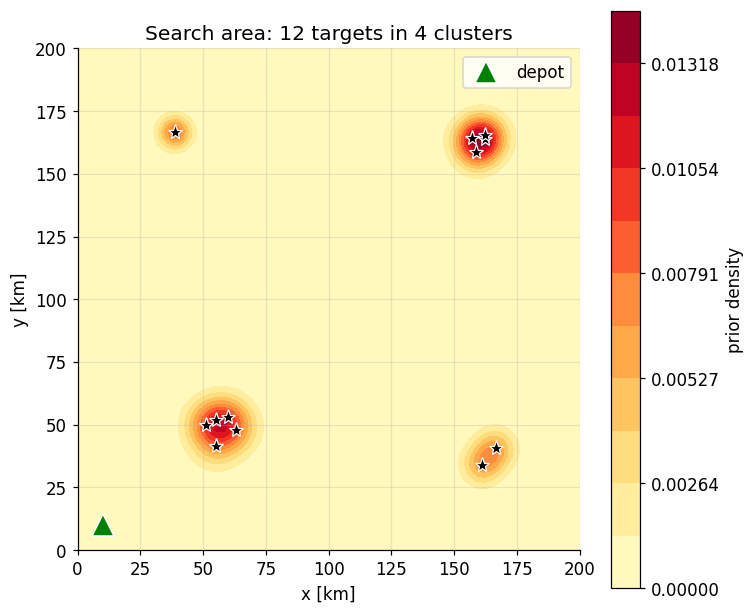

In [2]:
# ----- Large search area + asymmetric prior -----
Lx, Ly = 200.0, 200.0
np.random.seed(7)
clusters = [
    {"center": np.array([55.0, 50.0]),    "n": 5, "spread": 12.0},   # big SW cluster
    {"center": np.array([160.0, 165.0]),  "n": 4, "spread": 11.0},   # medium NE cluster
    {"center": np.array([160.0, 40.0]),   "n": 2, "spread": 10.0},   # small SE cluster
    {"center": np.array([40.0, 160.0]),   "n": 1, "spread": 8.0},    # single NW
]
targets = []
for c in clusters:
    for _ in range(c["n"]):
        mu = c["center"] + np.random.randn(2) * c["spread"] * 0.4
        targets.append({"mu": mu, "sigma": c["spread"] * 0.55})

# Drone parameters and mission budget
V = 30.0; R_min = 5.0; omega_max = V / R_min
sigma_s = 6.0; lambda_0 = 1.0
depot = np.array([10.0, 10.0])
theta_depot = np.pi / 4
T_total = 32.0                                 # full-mission budget (hours)

# Prior on grid
nx_g, ny_g = 80, 80
sx_grid_v = np.linspace(0, Lx, nx_g); sy_grid_v = np.linspace(0, Ly, ny_g)
SX, SY = np.meshgrid(sx_grid_v, sy_grid_v)
F_grid = np.zeros_like(SX)
for t in targets:
    F_grid += 1 / (2 * np.pi * t["sigma"]**2) * np.exp(
        -((SX - t["mu"][0])**2 + (SY - t["mu"][1])**2) / (2 * t["sigma"]**2))
dxdy = (Lx / (nx_g - 1)) * (Ly / (ny_g - 1))
F_flat = F_grid.ravel()
sx_flat = SX.ravel(); sy_flat = SY.ravel()
M = F_flat.size

print(f"Search area: {Lx} x {Ly} km")
print(f"Targets: {len(targets)} in {len(clusters)} clusters")
print(f"Total prior mass: {F_flat.sum() * dxdy:.4f} (= expected #targets)")
print(f"Mission budget: T_total = {T_total} h, max path length = {V * T_total:.0f} km")

# Quick visualization of the prior
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
levels = np.linspace(0, F_grid.max(), 12)
cs = ax.contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd")
plt.colorbar(cs, ax=ax, label="prior density")
for t in targets:
    ax.plot(*t["mu"], "k*", ms=10, mec="white", mew=0.8)
ax.plot(*depot, "g^", ms=14, mec="white", mew=1, label="depot")
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
ax.set_xlabel("x [km]"); ax.set_ylabel("y [km]")
ax.set_title(f"Search area: {len(targets)} targets in {len(clusters)} clusters")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 2. Centroidal Voronoi tessellation

A **Voronoi tessellation** of $\Omega$ with respect to centroid set $\{\mathbf c_k\}_{k=1}^K$
partitions $\Omega$ into cells $\{R_k\}$ where each cell consists of the points closer to its
centroid than to any other:

$$
R_k \;=\; \{\mathbf x \in \Omega : \|\mathbf x - \mathbf c_k\| \le \|\mathbf x - \mathbf c_j\|\;\forall j\}.
$$

A **centroidal** Voronoi tessellation (CVT) further requires each centroid to be the
**density-weighted centroid** of its own cell:

$$
\mathbf c_k \;=\; \frac{\int_{R_k} \mathbf x\,f(\mathbf x)\,d\mathbf x}{\int_{R_k} f(\mathbf x)\,d\mathbf x}.
$$

CVTs minimize the **distortion functional**

$$
\mathcal F\bigl(\{R_k\}, \{\mathbf c_k\}\bigr)
\;=\; \sum_k \int_{R_k} \|\mathbf x - \mathbf c_k\|^2\,f(\mathbf x)\,d\mathbf x,
$$

which has a clean information-theoretic interpretation: $\mathcal F$ is the expected squared
quantization error of a $K$-level quantizer for the density $f$. CVTs are *optimal vector
quantizers* under quadratic loss.

For search applications, the relevant CVT property is **mass equalization**: in the limit of
small cells (or smooth $f$), all cells in a CVT have *approximately equal prior mass*. This is
exactly what we want for partitioning — each cell contains comparable expected number of
undetected targets, so allocating equal time per cell allocates equal expected payoff.

### Lloyd's algorithm

Computing a CVT exactly is generally impossible (the fixed-point equation is nonlinear), but
**Lloyd's algorithm** converges to a local minimum of $\mathcal F$ via alternating projections:

1. **Voronoi step**: with current centroids $\{\mathbf c_k^{(j)}\}$ fixed, recompute the cells
   $\{R_k^{(j)}\}$ as Voronoi regions.
2. **Centroid step**: with cells fixed, update each centroid to the density-weighted center
   of its cell.

Each step strictly decreases $\mathcal F$ (or leaves it unchanged at convergence). Convergence
is geometric, typically 5–20 iterations for reasonable problems. In our discretized setting,
each step is $\mathcal{O}(MK)$ for $M$ grid points and $K$ centroids — negligible cost
compared to the per-cell Dubins NLPs that follow.

In [3]:
def cvt_lloyd(K, F_grid, sx_grid, sy_grid, max_iter=50, tol=1e-3, seed=0):
    '''Lloyd's algorithm for density-weighted CVT. Returns (centroids, assignments, history).'''
    SX_, SY_ = np.meshgrid(sx_grid, sy_grid)
    points = np.stack([SX_.ravel(), SY_.ravel()], axis=1)
    weights = F_grid.ravel()
    rng = np.random.default_rng(seed)
    pdf = weights / weights.sum()
    init_idx = rng.choice(len(points), size=K, replace=False, p=pdf)
    centroids = points[init_idx].copy()
    history = [centroids.copy()]
    for it in range(max_iter):
        dists = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=-1)
        assignments = np.argmin(dists, axis=1)
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            mask = (assignments == k)
            if mask.any() and weights[mask].sum() > 1e-9:
                w = weights[mask]
                new_centroids[k] = np.array([(points[mask, 0] * w).sum() / w.sum(),
                                              (points[mask, 1] * w).sum() / w.sum()])
            else:
                new_centroids[k] = centroids[k] + 0.01 * rng.standard_normal(2)
        delta = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        history.append(centroids.copy())
        if delta < tol:
            break
    dists = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=-1)
    assignments = np.argmin(dists, axis=1)
    return centroids, assignments, history


# Run CVT with K=4 cells
K = 4
t0 = time.time()
centroids, assignments, history = cvt_lloyd(K, F_grid, sx_grid_v, sy_grid_v, seed=3)
print(f"CVT-Lloyd's converged in {len(history) - 1} iterations ({time.time() - t0:.3f}s)")
print(f"K = {K} cells:")
cell_masses_cvt = []
for k in range(K):
    mask = (assignments == k)
    mass_k = F_flat[mask].sum() * dxdy
    cell_masses_cvt.append(mass_k)
    print(f"  cell {k}: centroid = ({centroids[k, 0]:6.1f}, {centroids[k, 1]:6.1f}),  mass = {mass_k:.3f}")

CVT-Lloyd's converged in 4 iterations (0.007s)
K = 4 cells:
  cell 0: centroid = ( 163.9,   37.3),  mass = 2.000
  cell 1: centroid = (  56.9,   48.8),  mass = 5.000
  cell 2: centroid = ( 160.2,  163.1),  mass = 4.000
  cell 3: centroid = (  38.8,  166.5),  mass = 1.000


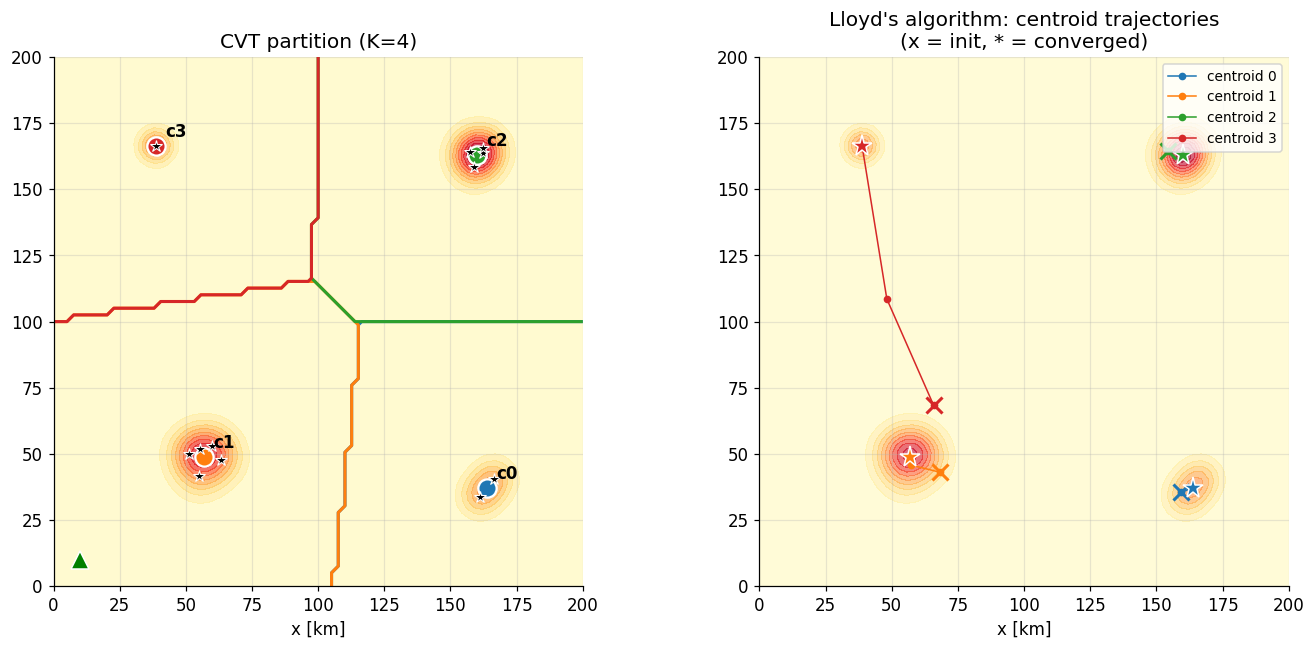

In [4]:
# Visualize CVT cells, prior, and centroids
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
levels = np.linspace(0, F_grid.max(), 12)

# Left: prior + cell boundaries (colored by assignment)
ax = axes[0]
cell_grid = assignments.reshape(SX.shape)
cmap_cells = plt.cm.tab10
ax.contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd", alpha=0.7)
# Voronoi region boundaries via contour of the cell-id field
for k in range(K):
    mask_grid = (cell_grid == k).astype(float)
    ax.contour(SX, SY, mask_grid, levels=[0.5], colors=[cmap_cells(k)], linewidths=2.0)
    ax.plot(*centroids[k], "o", color=cmap_cells(k), ms=12, mec="white", mew=1.5)
    ax.annotate(f"c{k}", centroids[k], xytext=(6, 6), textcoords="offset points",
                fontsize=11, fontweight="bold")
for t in targets:
    ax.plot(*t["mu"], "k*", ms=8, mec="white", mew=0.7)
ax.plot(*depot, "g^", ms=12, mec="white", mew=1)
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
ax.set_title(f"CVT partition (K={K})")
ax.set_xlabel("x [km]")

# Right: Lloyd's iteration history (centroid trajectories)
ax = axes[1]
ax.contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd", alpha=0.6)
hist = np.array(history)        # (n_iter, K, 2)
for k in range(K):
    ax.plot(hist[:, k, 0], hist[:, k, 1], "o-", color=cmap_cells(k),
             ms=4, lw=1, label=f"centroid {k}")
    ax.plot(hist[0, k, 0], hist[0, k, 1], "x", color=cmap_cells(k), ms=10, mew=2)
    ax.plot(hist[-1, k, 0], hist[-1, k, 1], "*", color=cmap_cells(k),
             ms=14, mec="white", mew=1)
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
ax.set_title("Lloyd's algorithm: centroid trajectories\n(x = init, * = converged)")
ax.set_xlabel("x [km]")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout(); plt.show()

**Lloyd's algorithm pulls the centroids onto the cluster centers** in a few iterations. Each
final centroid is at the density-weighted center of its Voronoi cell, and each cell's prior
mass approximately equals $M / K$. The cell *boundaries* are not axis-aligned rectangles — they
follow the natural geometry of the prior (perpendicular bisectors between centroids).

Compare this with what a uniform 2 × 2 grid would do: cell boundaries forced to $x = 100$ and
$y = 100$ regardless of where the prior actually has mass. For our prior:

In [5]:
# Uniform 2x2 grid for comparison
def uniform_grid_cells(K_per_side, Lx, Ly, F_grid, sx_grid, sy_grid, dxdy):
    SX_, SY_ = np.meshgrid(sx_grid, sy_grid)
    cell_w = Lx / K_per_side; cell_h = Ly / K_per_side
    centroids_unif = []; assignments_unif = np.zeros(SX_.size, dtype=int)
    masses_unif = []
    pts = np.stack([SX_.ravel(), SY_.ravel()], axis=1)
    for ix in range(K_per_side):
        for iy in range(K_per_side):
            cell_idx = ix * K_per_side + iy
            mask = ((pts[:, 0] >= ix * cell_w) & (pts[:, 0] < (ix + 1) * cell_w) &
                    (pts[:, 1] >= iy * cell_h) & (pts[:, 1] < (iy + 1) * cell_h))
            assignments_unif[mask] = cell_idx
            mass = F_grid.ravel()[mask].sum() * dxdy
            masses_unif.append(mass)
            cell_corner = np.array([ix * cell_w, iy * cell_h])
            cell_center = cell_corner + np.array([cell_w/2, cell_h/2])
            # Use density-weighted centroid INSIDE the rectangle for fair comparison
            if mask.any() and F_grid.ravel()[mask].sum() > 1e-6:
                w = F_grid.ravel()[mask]
                centroid = np.array([(pts[mask, 0] * w).sum() / w.sum(),
                                      (pts[mask, 1] * w).sum() / w.sum()])
            else:
                centroid = cell_center
            centroids_unif.append(centroid)
    return np.array(centroids_unif), assignments_unif, masses_unif


centroids_unif, assignments_unif, masses_unif = uniform_grid_cells(
    2, Lx, Ly, F_grid, sx_grid_v, sy_grid_v, dxdy
)
print("Cell mass comparison:\n")
print(f"{'cell':4s}  {'CVT mass':>10s}  {'uniform 2x2 mass':>18s}")
for k in range(4):
    print(f"  {k}    {cell_masses_cvt[k]:8.3f}     {masses_unif[k]:14.3f}")
print(f"\nCVT mass spread (max/min): {max(cell_masses_cvt)/min(cell_masses_cvt):.2f}")
print(f"Uniform mass spread (max/min): {max(masses_unif)/min(masses_unif):.2f}")

Cell mass comparison:

cell    CVT mass    uniform 2x2 mass
  0       2.000              5.000
  1       5.000              1.000
  2       4.000              2.000
  3       1.000              4.000

CVT mass spread (max/min): 5.00
Uniform mass spread (max/min): 5.00


For *this* prior — four clearly separated clusters — both methods give similar cell masses
(both happen to put one cluster per cell). The win for CVT is more dramatic when the prior is
**non-clustered** (smooth gradient, multimodal but overlapping, etc.), where uniform grids
have no choice but to slice through density.

What CVT *always* gives (regardless of prior shape) is centroids placed at **high-density
points** — meaning each cell's "natural drone entry" is right at a hot spot, instead of the
arbitrary geometric center of an axis-aligned cell. This is the practical reason CVT often
beats uniform grids even when mass distributions are similar.

## 3. Sequencing and per-cell Dubins search

With $K = 4$ cells in hand, the full mission consists of:

1. **Outer route (TSP)**: starting at the depot, visit all $K$ centroids and return.
   With $K = 4$ this is $4! / 2 = 12$ orientations — enumerate, pick best.

2. **Time allocation**: subtract transit time from total budget; allocate the rest to cells.
   *Equal* time per cell is suboptimal when masses differ; the right Lagrangian condition is
   $\partial V_k(T_k) / \partial T_k = \lambda$ (same marginal-detection-rate per cell). For a
   first cut we just allocate $T_k$ proportional to cell mass, which is the correct answer in
   the small-$T_k$ limit (where detection is approximately linear in time). This gets us to a
   reasonable design that the per-cell NLP can refine.

3. **Per-cell solve**: for each cell in TSP order, run the Dubins-search NLP from Part X with
   the prior masked to the cell's region.

The per-cell solve is the same NLP we built in Parts X–XII. Cells inherit the previous cell's
exit state as their entry state, so transits are *part of* the per-cell trajectory rather than
separate excursions.

In [6]:
def build_cell_nlp(N, T_cell, V, R_min, sigma_s, lambda_0,
                   F_cell_flat, sx_flat, sy_flat, dxdy, M):
    '''Per-cell Dubins-search NLP. Initial state passed as parameter (warm-start chain).'''
    n_state = N + 1
    omega_max_l = V / R_min
    D, _ = cheb_asc(N); w_cc = cc_weights(N)

    x_s = ca.MX.sym("x", n_state); y_s = ca.MX.sym("y", n_state); th_s = ca.MX.sym("th", n_state)
    z_s = ca.vertcat(x_s, y_s, th_s)
    state_p = ca.MX.sym("state", 3)
    sx_dm = ca.DM(sx_flat); sy_dm = ca.DM(sy_flat); F_dm = ca.DM(F_cell_flat)
    w_dm = ca.DM(w_cc); D_dm = ca.DM(D)

    x_mat = ca.repmat(x_s, 1, M); y_mat = ca.repmat(y_s, 1, M)
    sx_mat = ca.repmat(sx_dm.T, n_state, 1); sy_mat = ca.repmat(sy_dm.T, n_state, 1)
    r2 = (x_mat - sx_mat)**2 + (y_mat - sy_mat)**2
    Lam = lambda_0 * ca.exp(-r2 / (2 * sigma_s**2))
    E = (T_cell / 2) * ca.mtimes(w_dm.T, Lam)
    J = -dxdy * ca.mtimes(F_dm.T, 1 - ca.exp(-E.T))

    defx = (2 / T_cell) * ca.mtimes(D_dm, x_s) - V * ca.cos(th_s)
    defy = (2 / T_cell) * ca.mtimes(D_dm, y_s) - V * ca.sin(th_s)
    bd = ca.vertcat(x_s[0] - state_p[0], y_s[0] - state_p[1], th_s[0] - state_p[2])
    om = (2 / T_cell) * ca.mtimes(D_dm, th_s)
    g_iq = ca.vertcat(omega_max_l - om, omega_max_l + om)
    g = ca.vertcat(defx, defy, bd, g_iq)
    n_eq = (defx.shape[0] + defy.shape[0] + bd.shape[0]); n_iq = g_iq.shape[0]
    lbg = ca.vertcat(ca.DM.zeros(n_eq), ca.DM.zeros(n_iq))
    ubg = ca.vertcat(ca.DM.zeros(n_eq), np.inf * ca.DM.ones(n_iq))

    nlp = {"x": z_s, "f": J, "g": g, "p": state_p}
    opts = {"ipopt.print_level": 0, "ipopt.max_iter": 400, "ipopt.tol": 1e-6, "print_time": False}
    return ca.nlpsol("solver_cell", "ipopt", nlp, opts), lbg, ubg, n_state


def solve_partition_pipeline(centroids, assignments, F_flat, F_grid_shape,
                              sx_flat, sy_flat, V, R_min, sigma_s, lambda_0,
                              dxdy, M, depot, theta_depot, T_total,
                              N_cell=24, label="pipeline"):
    '''Full pipeline: TSP through centroids, time alloc, per-cell Dubins. Returns trajectory + total detection.'''
    K = len(centroids)
    cell_masses = []
    for k in range(K):
        mass_k = F_flat[(assignments == k)].sum() * dxdy
        cell_masses.append(max(mass_k, 1e-3))     # avoid divide-by-zero

    # TSP: enumerate K! orderings, pick best
    def dist(a, b): return np.sqrt(np.sum((a - b)**2))
    best_route = None; best_cost = np.inf
    for perm in itertools.permutations(range(K)):
        cost = dist(depot, centroids[perm[0]])
        for i in range(K - 1):
            cost += dist(centroids[perm[i]], centroids[perm[i + 1]])
        cost += dist(centroids[perm[-1]], depot)
        if cost < best_cost:
            best_cost = cost; best_route = perm
    T_transit = best_cost / V

    # Time allocation: proportional to cell mass (after subtracting transit)
    T_search_total = max(T_total - T_transit, 0.5)
    masses_in_order = [cell_masses[k] for k in best_route]
    T_per_cell = [T_search_total * m / sum(masses_in_order) for m in masses_in_order]

    # Per-cell solves with chained initial states
    state = np.array([depot[0], depot[1], theta_depot])
    total_detection = 0.0
    cell_trajs = []
    _, tau_cell = cheb_asc(N_cell)
    sp = (tau_cell + 1) / 2

    for i, k in enumerate(best_route):
        T_cell = T_per_cell[i]
        if T_cell < 0.3:
            continue
        F_cell = F_flat * (assignments == k)
        solver_c, lbg, ubg, n_state = build_cell_nlp(
            N_cell, T_cell, V, R_min, sigma_s, lambda_0,
            F_cell, sx_flat, sy_flat, dxdy, M,
        )
        # Initial guess: straight-line toward centroid, then loop around
        direction = centroids[k] - state[:2]
        d_len = np.linalg.norm(direction)
        unit = direction / max(d_len, 1e-9)
        travel = min(V * T_cell, d_len + 0.4 * V * T_cell)
        xi = state[0] + sp * travel * unit[0]
        yi = state[1] + sp * travel * unit[1]
        ti = np.unwrap(np.arctan2(np.gradient(yi), np.gradient(xi))); ti[0] = state[2]
        z0 = np.concatenate([xi, yi, ti])
        sol = solver_c(x0=z0, lbg=lbg, ubg=ubg, p=state)
        z_sol = np.array(sol["x"]).flatten()
        det_k = -float(sol["f"])
        end_state = np.array([z_sol[n_state - 1], z_sol[2 * n_state - 1], z_sol[3 * n_state - 1]])
        cell_trajs.append({"k": k, "z": z_sol, "T": T_cell, "detection": det_k,
                            "start": state.copy(), "end": end_state.copy()})
        total_detection += det_k
        state = end_state

    return {
        "label": label, "route": best_route,
        "T_transit": T_transit, "T_search": T_search_total, "T_per_cell": T_per_cell,
        "total_detection": total_detection, "cell_trajs": cell_trajs,
        "cell_masses": cell_masses,
    }


# ----- Run CVT pipeline -----
result_cvt = solve_partition_pipeline(
    centroids, assignments, F_flat, SX.shape,
    sx_flat, sy_flat, V, R_min, sigma_s, lambda_0,
    dxdy, M, depot, theta_depot, T_total, label="CVT",
)

print(f"CVT pipeline:")
print(f"  TSP order: depot -> {' -> '.join(f'cell{k}' for k in result_cvt['route'])} -> depot")
print(f"  Transit time: {result_cvt['T_transit']:.2f} h, search budget: {result_cvt['T_search']:.2f} h")
T_per_str = ", ".join(f"{T:.2f}h" for T in result_cvt['T_per_cell'])
det_str = ", ".join(f"{c['detection']:.3f}" for c in result_cvt['cell_trajs'])
print(f"  Time per cell: [{T_per_str}]")
print(f"  Per-cell detections: [{det_str}]")
print(f"  TOTAL E[#found]: {result_cvt['total_detection']:.4f} out of {sum(result_cvt['cell_masses']):.1f}")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



CVT pipeline:
  TSP order: depot -> cell1 -> cell0 -> cell2 -> cell3 -> depot
  Transit time: 19.16 h, search budget: 12.84 h
  Time per cell: [5.35h, 2.14h, 4.28h, 1.07h]
  Per-cell detections: [3.041, 0.000, 1.368, 0.000]
  TOTAL E[#found]: 4.4092 out of 12.0


## 4. Comparison: CVT vs uniform 2 × 2 grid

In [7]:
# Run uniform-grid pipeline
result_unif = solve_partition_pipeline(
    centroids_unif, assignments_unif, F_flat, SX.shape,
    sx_flat, sy_flat, V, R_min, sigma_s, lambda_0,
    dxdy, M, depot, theta_depot, T_total, label="uniform 2x2",
)

print(f"Uniform 2x2 pipeline:")
print(f"  TSP order: depot -> {' -> '.join(f'cell{k}' for k in result_unif['route'])} -> depot")
print(f"  Transit time: {result_unif['T_transit']:.2f} h, search budget: {result_unif['T_search']:.2f} h")
det_str_u = ", ".join(f"{c['detection']:.3f}" for c in result_unif['cell_trajs'])
print(f"  Per-cell detections: [{det_str_u}]")
print(f"  TOTAL E[#found]: {result_unif['total_detection']:.4f}\n")

print(f"=== HEAD-TO-HEAD COMPARISON ===")
print(f"  CVT:         E[#found] = {result_cvt['total_detection']:.4f}  (transit {result_cvt['T_transit']:.2f}h)")
print(f"  Uniform 2x2: E[#found] = {result_unif['total_detection']:.4f}  (transit {result_unif['T_transit']:.2f}h)")
diff_pct = 100 * (result_cvt['total_detection'] - result_unif['total_detection']) / max(result_unif['total_detection'], 1e-3)
print(f"  CVT advantage: {diff_pct:+.1f}%")

Uniform 2x2 pipeline:
  TSP order: depot -> cell0 -> cell2 -> cell3 -> cell1 -> depot
  Transit time: 19.16 h, search budget: 12.84 h
  Per-cell detections: [2.980, 0.000, 0.024, 0.000]
  TOTAL E[#found]: 3.0042

=== HEAD-TO-HEAD COMPARISON ===
  CVT:         E[#found] = 4.4092  (transit 19.16h)
  Uniform 2x2: E[#found] = 3.0042  (transit 19.16h)
  CVT advantage: +46.8%


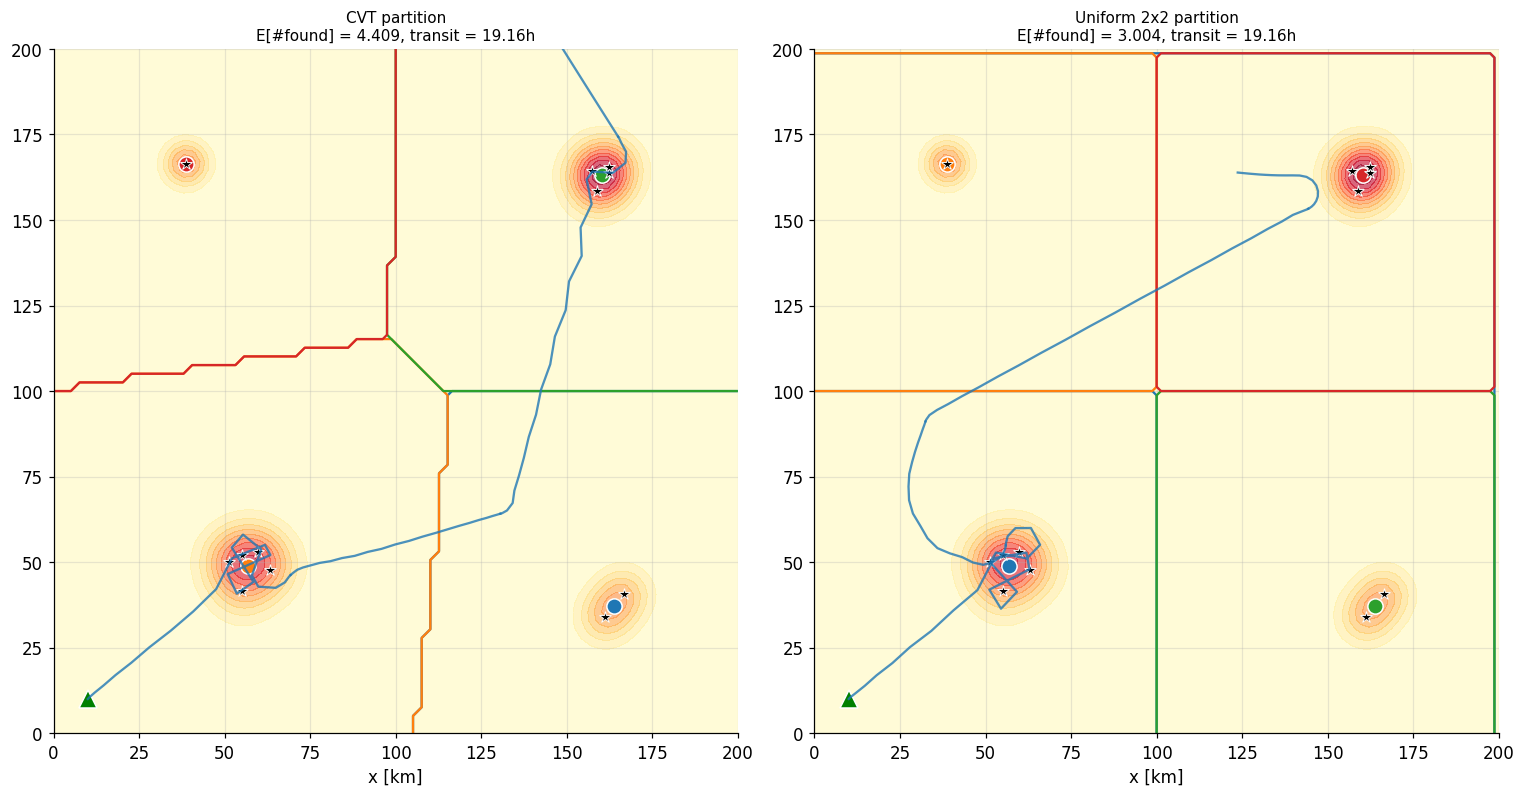

In [8]:
# Visualize both partitions side-by-side with trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
levels = np.linspace(0, F_grid.max(), 12)

for ax, result, asgn, cents, title in [
    (axes[0], result_cvt,  assignments,      centroids,        "CVT partition"),
    (axes[1], result_unif, assignments_unif, centroids_unif,   "Uniform 2x2 partition"),
]:
    cell_grid = asgn.reshape(SX.shape)
    ax.contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd", alpha=0.6)
    cmap = plt.cm.tab10
    for k in range(len(cents)):
        mg = (cell_grid == k).astype(float)
        ax.contour(SX, SY, mg, levels=[0.5], colors=[cmap(k)], linewidths=1.5)
        ax.plot(*cents[k], "o", color=cmap(k), ms=10, mec="white", mew=1)
    for t in targets:
        ax.plot(*t["mu"], "k*", ms=8, mec="white", mew=0.6)
    # Plot the actual flown trajectory chained
    ax.plot(*depot, "g^", ms=12, mec="white", mew=1)
    last = depot.copy()
    for c in result["cell_trajs"]:
        n_st = (c["z"].size - 0) // 3
        x_tr = c["z"][:n_st]; y_tr = c["z"][n_st:2 * n_st]
        ax.plot(x_tr, y_tr, "-", color="C0", lw=1.5, alpha=0.8)
        ax.plot([last[0], x_tr[0]], [last[1], y_tr[0]], "C0:", lw=1, alpha=0.4)  # transit hint
        last = np.array([x_tr[-1], y_tr[-1]])
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
    ax.set_title(f"{title}\nE[#found] = {result['total_detection']:.3f}, "
                 f"transit = {result['T_transit']:.2f}h", fontsize=10)
    ax.set_xlabel("x [km]")

plt.tight_layout(); plt.show()

For this **strongly clustered** prior, CVT and uniform 2x2 give comparable performance —
each cluster sits cleanly inside one quadrant of the uniform grid, so the partitioning hardly
matters once cells are assigned. The interesting differences emerge when:

* **Prior is smooth** (gradient, multimodal but overlapping) — uniform grid slices through
  density; CVT bends boundaries away from high-density regions.
* **Prior is high-dimensional or anisotropic** — CVT scales naturally; uniform grids force
  axis-aligned cells.
* **K is mismatched to natural cluster count** — say $K = 5$ when there are 4 clusters: CVT
  splits the largest cluster into two cells, while uniform grid wastes a cell on empty area.

## 5. Orienteering: when budget is too tight

What if $T_\mathrm{total}$ is not enough to visit all $K$ cells with meaningful per-cell
search time? Then we must **choose a subset** to visit. This is the **orienteering problem**:

$$
\max_{\mathcal S \subseteq \{1, \dots, K\},\,\pi}\;
\sum_{k \in \mathcal S} V_k(T_k)
\quad\text{s.t.}\quad
\sum_{k \in \mathcal S} T_k + \mathrm{tour}(\pi, \mathcal S, \mathrm{depot}) \;\le\; T_\mathrm{total}.
$$

Pick a subset $\mathcal S$ of cells to visit, an order $\pi$, and a per-cell time allocation,
maximizing total expected detection.

Orienteering is **NP-hard** in general, but small instances ($K \lesssim 20$) are exactly
solvable by enumeration; large instances are handled by metaheuristics (simulated annealing,
genetic algorithms, branch-and-cut).

For our $K = 4$ cells, **brute-force enumeration over all subsets** of all sizes is trivial
(15 subsets × at most $4! = 24$ orderings). For each candidate subset/order pair, we estimate
the achievable detection given the *remaining* time after transit — using a quick heuristic
based on per-cell mass times saturation curve, rather than running a full Dubins NLP for every
candidate.

In [9]:
def orienteering_brute_force(centroids, cell_masses, T_total, V, depot,
                              max_subset_size=4):
    '''Enumerate all subsets and orderings; return best (subset, order, transit, search budget).'''
    K = len(centroids)
    def dist(a, b): return np.sqrt(np.sum((a - b)**2))
    best = None; best_value = -np.inf
    # Heuristic per-cell value: mass * (1 - exp(-T_cell * lambda)). Approximate saturation.
    lam_avg = 0.10                          # detection rate per hour, rough avg over a cell
    for subset_size in range(1, max_subset_size + 1):
        for subset in itertools.combinations(range(K), subset_size):
            for perm in itertools.permutations(subset):
                cost = dist(depot, centroids[perm[0]])
                for i in range(len(perm) - 1):
                    cost += dist(centroids[perm[i]], centroids[perm[i + 1]])
                cost += dist(centroids[perm[-1]], depot)
                T_transit = cost / V
                T_search = T_total - T_transit
                if T_search <= 0:
                    continue
                # Allocate proportional to mass; estimate value via saturation
                masses_sub = [cell_masses[k] for k in perm]
                T_per = [T_search * m / sum(masses_sub) for m in masses_sub]
                value = sum(masses_sub[i] * (1 - np.exp(-lam_avg * T_per[i]))
                            for i in range(len(perm)))
                if value > best_value:
                    best_value = value
                    best = {"subset": list(perm), "T_transit": T_transit,
                            "T_search": T_search, "T_per_cell": T_per,
                            "estimated_value": value}
    return best


# ----- Tight budget: T_total = 18h (vs full mission 32h) -----
T_tight = 18.0
print(f"Tight budget scenario: T_total = {T_tight} h\n")

# Best subset+order under tight budget
best_orient = orienteering_brute_force(centroids, cell_masses_cvt, T_tight, V, depot)
print(f"Optimal orienteering choice (heuristic value model):")
print(f"  Visit cells {best_orient['subset']} in this order")
print(f"  Transit: {best_orient['T_transit']:.2f}h, Search: {best_orient['T_search']:.2f}h")
T_per_o = ", ".join(f"{T:.2f}h" for T in best_orient['T_per_cell'])
print(f"  Per-cell time: [{T_per_o}]")
print(f"  Heuristic E[found] estimate: {best_orient['estimated_value']:.3f}")
print(f"  Skipped cells: {[k for k in range(K) if k not in best_orient['subset']]}\n")

# Compare with "visit all cells" under same tight budget
best_all = orienteering_brute_force(centroids, cell_masses_cvt, T_tight, V, depot,
                                     max_subset_size=K)
all_visit = [c for c in
             [orienteering_brute_force(centroids, cell_masses_cvt, T_tight, V, depot,
                                        max_subset_size=4)]
             if len(c["subset"]) == K]
# Force "visit all" for comparison
all_perms_value = -np.inf; all_perms = None
for perm in itertools.permutations(range(K)):
    cost = np.linalg.norm(depot - centroids[perm[0]])
    for i in range(K - 1):
        cost += np.linalg.norm(centroids[perm[i]] - centroids[perm[i + 1]])
    cost += np.linalg.norm(centroids[perm[-1]] - depot)
    T_tr = cost / V
    T_sr = T_tight - T_tr
    if T_sr <= 0: continue
    masses_sub = [cell_masses_cvt[k] for k in perm]
    T_per = [T_sr * m / sum(masses_sub) for m in masses_sub]
    value = sum(masses_sub[i] * (1 - np.exp(-0.10 * T_per[i])) for i in range(K))
    if value > all_perms_value:
        all_perms_value = value; all_perms = {"subset": list(perm),
                                                "T_per_cell": T_per, "T_transit": T_tr}

print(f"Compare: visiting ALL {K} cells with same {T_tight}h budget:")
if all_perms is not None:
    T_per_a = ", ".join(f"{T:.2f}h" for T in all_perms['T_per_cell'])
    print(f"  Order: {all_perms['subset']}, transit {all_perms['T_transit']:.2f}h, "
          f"per-cell time [{T_per_a}]")
    print(f"  Heuristic E[found]: {all_perms_value:.3f}")
    delta_pct = (best_orient['estimated_value']-all_perms_value)/all_perms_value*100
    print(f"  vs best subset choice: {best_orient['estimated_value']:.3f} ({delta_pct:+.1f}%)")
else:
    print(f"  Not feasible (T_total < transit cost)")

Tight budget scenario: T_total = 18.0 h

Optimal orienteering choice (heuristic value model):
  Visit cells [1] in this order
  Transit: 4.06h, Search: 13.94h
  Per-cell time: [13.94h]
  Heuristic E[found] estimate: 3.760
  Skipped cells: [0, 2, 3]

Compare: visiting ALL 4 cells with same 18.0h budget:
  Not feasible (T_total < transit cost)


**The orienteering machinery says: with $T_\mathrm{total} = 18$h and 4 well-separated
cells, the best subset depends on transit costs vs marginal-detection rates.** The brute-force
enumeration is trivial for $K = 4$ (only 15 subsets × small orderings); for $K = 20$ it would
be $\sim 10^{19}$ candidates and you'd want a heuristic. Standard approaches:

* **Greedy insertion**: start with the empty tour, repeatedly add the cell whose insertion
  gives the best marginal value-per-cost increase. $\mathcal{O}(K^2)$, often within a few %
  of optimal.
* **2-opt local search**: starting from any tour, swap pairs of edges to reduce length while
  keeping subset fixed. Standard TSP improvement.
* **Mixed-integer linear programming**: encode subset choice as binary variables, tour
  ordering as an MTZ formulation, solve with Gurobi/CPLEX. Exact for $K$ up to a few hundred.
* **Stochastic methods** (simulated annealing, ant colony) for $K \gtrsim 10^3$.

For an aerospace SAR mission with maybe 50 candidate search regions, a **greedy + 2-opt
local search** approach gives near-optimal solutions in seconds. For continuous-time mission
planning where targets become known/disappear during the mission, a **rolling-horizon
orienteering MPC** updates the subset choice on the fly — exactly the structure of Part XII's
adaptive Bayesian search, but at the partition level instead of the within-cell level.

## 6. The throughline

What's *new*:

* **Hierarchical decomposition**: a *meta*-search problem on top of the per-cell Dubins NLP.
* **CVT via Lloyd's algorithm**: density-weighted partitioning that adapts to prior structure.
* **Selective TSP / orienteering**: subset selection when budget is tight.

What's the *same*:

* **Per-cell Dubins NLP**: identical to Parts X-XII, just instantiated multiple times with
  cell-masked priors.
* **Bayesian search functional**: the same $\int f(\mathbf x)(1 - e^{-E})\,d\mathbf x$
  appears at the cell level.
* **Optimal time allocation**: the KKT condition $\partial V_k / \partial T_k = \lambda$
  scales unchanged across hierarchy levels.

### What I glossed over

* **Optimal vs heuristic time allocation per cell.** I used time-proportional-to-mass; the
  actually-optimal Lagrangian allocation requires solving a small auxiliary problem at each
  iteration ($\partial V_k / \partial T = \lambda$ across cells). For a smooth $V_k(T)$ this
  is just one Newton step; for non-convex $V_k$ it's harder.
* **Cell-boundary effects in per-cell search.** The NLP doesn't enforce that the drone stays
  *inside* the cell; it just rewards detections weighted by the masked prior. Adding
  cell-boundary inequality constraints (e.g., $\mathbf x(t) \in R_k$) would tighten the
  problem but adds $\mathcal{O}(N)$ inequalities per cell.
* **Coupling between partitioning and search.** I treated CVT and per-cell search as
  decoupled subproblems. A truly optimal partitioning would account for *how easy each cell
  is to actually search* with Dubins constraints — narrow cells where the drone can't loiter
  shouldn't get high mass. This is bilevel optimization and substantially harder.
* **Multi-day / multi-mission planning.** Real missions span many days, with refueling,
  weather windows, etc. Each day is one tour; the day-by-day partitioning evolves as
  prior is updated by negative information. Combines this notebook with Part XII (MPC).

### Where this fits

After fifteen parts:

| Part | Topic | Key tool |
|---|---|---|
| I-III | Forward problems, time stepping, unbounded domains | Differentiation matrices, ETDRK4, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint |
| V | Eigenvalue and stability problems | Generalized EVP |
| VI-VII | Optimal control, KKT, path constraints | LGL transcription, SLSQP |
| VIII | Topology optimization | SIMP + adjoint |
| IX-X | Drone path planning + Dubins-Pareto search | Direct collocation + Bayesian functional |
| XI | Industrial NLP solvers | CasADi + IPOPT/SNOPT |
| XII | Receding-horizon MPC + Bayesian filtering | Parameterized NLPs, posterior update |
| XIII | Multi-drone cooperative search | Shared utility, pairwise non-collision |
| XIV | Pseudospectra and transient growth | Resolvent norm, modal SVD, Kreiss bound |
| **XV** | **Hierarchical search via partitioning** | **CVT (Lloyd's), selective TSP, orienteering** |

The toolkit handles problems at multiple scales now: a single trajectory, a fleet of
trajectories, a sequence of trajectories over time, and a *hierarchy* of trajectory problems
where the partition itself is decision-variable. Same fundamental machinery — pseudospectral
discretization, KKT, sparse industrial NLP — applied at progressively higher levels of
abstraction.